<a href="https://colab.research.google.com/github/ionutbirescu/lyrics-data-mining/blob/main/GeniusLyrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Are Lyrics Getting Simpler and More Negative? A Data-Driven check
Ionuț Birescu, Cristina Ioja

##KAGGLE Dataset (this is where the project begins)

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()   # select your kaggle.json here

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ionubirescu","key":"d7e9e37d3b80ba779db46b3c1be88bb5"}'}

In [2]:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d carlosgdcj/genius-song-lyrics-with-language-information
!unzip -q genius-song-lyrics-with-language-information.zip
!ls -lh *.csv

Dataset URL: https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information
License(s): unknown
genius-song-lyrics-with-language-information.zip: Skipping, found more recently modified local copy (use --force to force download)
replace song_lyrics.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: -rw-r--r-- 1 root root  22M Jun 21 19:39 lyrics_clean.csv
-rw-r--r-- 1 root root 6.5M Jun 21 18:34 lyrics_raw.csv
-rw-r--r-- 1 root root 8.5G Jan 11  2023 song_lyrics.csv


###Preprocessing

We start from a massive lyrics file - 9 GB - so we read it bit by bit and keep only English songs, from 4 genres (pop, rock, rap, R&B) released between 1980 and 2025. Each song gets labeled with its decade so we can track how things change over time. Since some decades may have more songs that others, we trim each group down to 200 so we get a balanced set for lyrics_raw.csv to work with from here on.

In [3]:
import pandas as pd

PATH = "song_lyrics.csv"          # change if Cell 2's ls showed a different name
GENRES = ["pop", "rock","rb"]
PER_CELL = 200                    # songs per genre x decade

frames = []
for chunk in pd.read_csv(PATH, chunksize=200_000,
                         usecols=["title", "artist", "tag", "year", "language", "lyrics"]):
    chunk = chunk[
        (chunk["language"] == "en") &
        (chunk["tag"].isin(GENRES)) &
        (chunk["year"].between(1980, 2025))
    ].copy()
    chunk["decade"] = (chunk["year"] // 10 * 10).astype(int).astype(str) + "s"
    frames.append(chunk)

df = pd.concat(frames, ignore_index=True)

# balance: cap each genre x decade cell so no group dominates
df = (df.groupby(["tag", "decade"], group_keys=False)
        .apply(lambda g: g.sample(min(len(g), PER_CELL), random_state=42)))

df = df.rename(columns={"tag": "genre"})[
    ["artist", "title", "lyrics", "genre", "year", "decade"]
].reset_index(drop=True)

df.to_csv("lyrics_raw.csv", index=False)
print("shape:", df.shape)
print(df.groupby(["genre", "decade"]).size())

/tmp/ipykernel_35447/3666035552.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), PER_CELL), random_state=42)))


shape: (3000, 6)
genre  decade
pop    1980s     200
       1990s     200
       2000s     200
       2010s     200
       2020s     200
rb     1980s     200
       1990s     200
       2000s     200
       2010s     200
       2020s     200
rock   1980s     200
       1990s     200
       2000s     200
       2010s     200
       2020s     200
dtype: int64


The dataset came mostly pre-cleaned so we only strip: Verge/Chorus tags, multispaces, non-words etc. We then create two versions of each song - a light one that keeps negations like "not"/"never" for sentiment and a heavier one with stopwords removed and words lemmatized for TF-IDF, the model and search.

In [4]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

_SECTION_TAG  = re.compile(r"\[.*?\]")
_WEIRD_SPACES = re.compile(r"[\u2005\u200b\u00a0\u2009\u202f]")
_MULTISPACE   = re.compile(r"[ \t]+")
_MULTINEWLINE = re.compile(r"\n{2,}")
_NON_WORD     = re.compile(r"[^a-z'\s]")

def clean_text(raw):
    if not isinstance(raw, str):
        return ""
    t = raw  # Initialize 't' with the raw input
    t = _SECTION_TAG.sub(" ", t)
    t = _WEIRD_SPACES.sub(" ", t)
    t = _MULTISPACE.sub(" ", t)
    t = _MULTINEWLINE.sub("\n", t)
    return t.strip().lower()

def tokenize(clean):
    """Heavy pipeline: drop punctuation/digits -> remove stopwords -> lemmatize. For TF-IDF / model / IR."""
    if not clean:
        return []
    out = []
    for w in _NON_WORD.sub(" ", clean).split():
        w = w.strip("'")
        if len(w) < 3 or w in STOPWORDS:
            continue
        out.append(LEMMATIZER.lemmatize(w))
    return out

def preprocess_dataframe(df, text_col="lyrics", min_words=20):
    """Add clean_text, tokens, tokens_str, word_count, unique_word_count, ttr; drop too-short/duplicate rows."""
    df = df.copy()
    df["clean_text"]        = df[text_col].apply(clean_text)
    df["tokens"]            = df["clean_text"].apply(tokenize)
    df["tokens_str"]        = df["tokens"].apply(lambda toks: " ".join(toks))
    df["word_count"]        = df["tokens"].apply(len)
    df["unique_word_count"] = df["tokens"].apply(lambda toks: len(set(toks)))
    df["ttr"]               = df.apply(
        lambda r: r["unique_word_count"] / r["word_count"] if r["word_count"] else 0.0, axis=1)

    before = len(df)
    df = df[df["word_count"] >= min_words]
    df = df.drop_duplicates(subset="clean_text").reset_index(drop=True)
    print(f"[preprocess] kept {len(df)}/{before} rows ({before - len(df)} dropped: too-short/duplicate)")
    return df

df = pd.read_csv("lyrics_raw.csv")
df = preprocess_dataframe(df)
df.to_csv("lyrics_clean.csv", index=False)
print("shape:", df.shape)
df.head(3)

[preprocess] kept 2970/3000 rows (30 dropped: too-short/duplicate)
shape: (2970, 12)


,artist,title,lyrics,genre,year,decade,clean_text,tokens,tokens_str,word_count,unique_word_count,ttr
0,D-A-D,Theres A Ship,I got a lord of my own\nAnd I got him at home\...,pop,1987,1980s,i got a lord of my own\nand i got him at home\...,"[got, lord, got, home, one, trust, say, must, ...",got lord got home one trust say must friendly ...,79,51,0.645570
1,Survivor,Chevy Nights,When trouble's on my mind I like to reminisce\...,pop,1981,1980s,when trouble's on my mind i like to reminisce\...,"[trouble's, mind, like, reminisce, simpler, ti...",trouble's mind like reminisce simpler time nig...,56,45,0.803571
2,Brian Setzer,Summertime Blues,"Let's rock it now\n\nWell, I'm a-gonna raise a...",pop,1987,1980s,"let's rock it now\nwell, i'm a-gonna raise a f...","[let's, rock, well, gonna, raise, fuss, gonna,...",let's rock well gonna raise fuss gonna raise h...,104,64,0.615385


In [11]:
from google.colab import files
files.download("lyrics_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###TF-IDF

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

df = pd.read_csv("lyrics_clean.csv")
df["tokens_str"] = df["tokens_str"].fillna("")

vectorizer = TfidfVectorizer(
    max_features=5000,   # cap vocabulary size
    min_df=5,            # ignore words in fewer than 5 songs (noise)
    max_df=0.5,          # ignore words in >50% of songs (too common to be useful)
    sublinear_tf=True,   # dampen very high counts (1+log tf)
)
X = vectorizer.fit_transform(df["tokens_str"])
terms = np.array(vectorizer.get_feature_names_out())
print("TF-IDF matrix:", X.shape)

def top_distinctive(group_col, n=12):
    """Words whose mean TF-IDF is highest in the group RELATIVE to the rest of the corpus."""
    out = {}
    for g in sorted(df[group_col].unique()):
        mask = (df[group_col] == g).values
        in_mean  = np.asarray(X[mask].mean(axis=0)).ravel()
        out_mean = np.asarray(X[~mask].mean(axis=0)).ravel()
        diff = in_mean - out_mean
        idx = diff.argsort()[::-1][:n]
        out[g] = list(zip(terms[idx], diff[idx]))
    return out

genre_words  = top_distinctive("genre")
decade_words = top_distinctive("decade")

print("\nMost distinctive words per GENRE:")
for g, w in genre_words.items():
    print(f"  {g:8}: {', '.join(t for t, _ in w)}")

print("\nMost distinctive words per DECADE:")
for d, w in decade_words.items():
    print(f"  {d:8}: {', '.join(t for t, _ in w)}")

# save for the model step (reuse the SAME vectorizer/matrix)
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(X, "tfidf_matrix.joblib")

TF-IDF matrix: (2970, 3757)

Most distinctive words per GENRE:
  pop     : turning, voice, gone, home, chorus, fall, falling, wind, fell, blue, step, who
  rb      : baby, yeah, love, girl, ooh, wanna, ain, got, need, cause, want, make
  rock    : death, light, burn, dead, kill, hand, broken, nothing, fire, away, left, land

Most distinctive words per DECADE:
  1980s   : love, there, well, ooh, night, baby, around, hey, boy, little, give, dream
  1990s   : yes, little, man, need, baby, doo, cry, fool, die, way, gonna, sweet
  2000s   : hey, born, live, done, cause, silence, touch, sexy, word, ain, far, all
  2010s   : leave, lost, hook, body, broken, shit, nothing, fight, verse, fuck, fucking, nigga
  2020s   : fuck, verse, like, shit, wanna, bitch, tryna, chorus, fucking, feeling, feel, stuck


['tfidf_matrix.joblib']

We excluded the rap genre from our genre-level analysis. Its most distinctive vocabulary is dominated by explicit language and slurs, which we judged inappropriate to foreground in an academic presentation. We note this is an editorial choice, not a data-quality one: rap is a linguistically rich genre, and its exclusion narrows our genre comparison to pop, rock, and R&B — three genres with more comparable registers, which also makes the classification task more challenging and the genre distinctions more subtle.

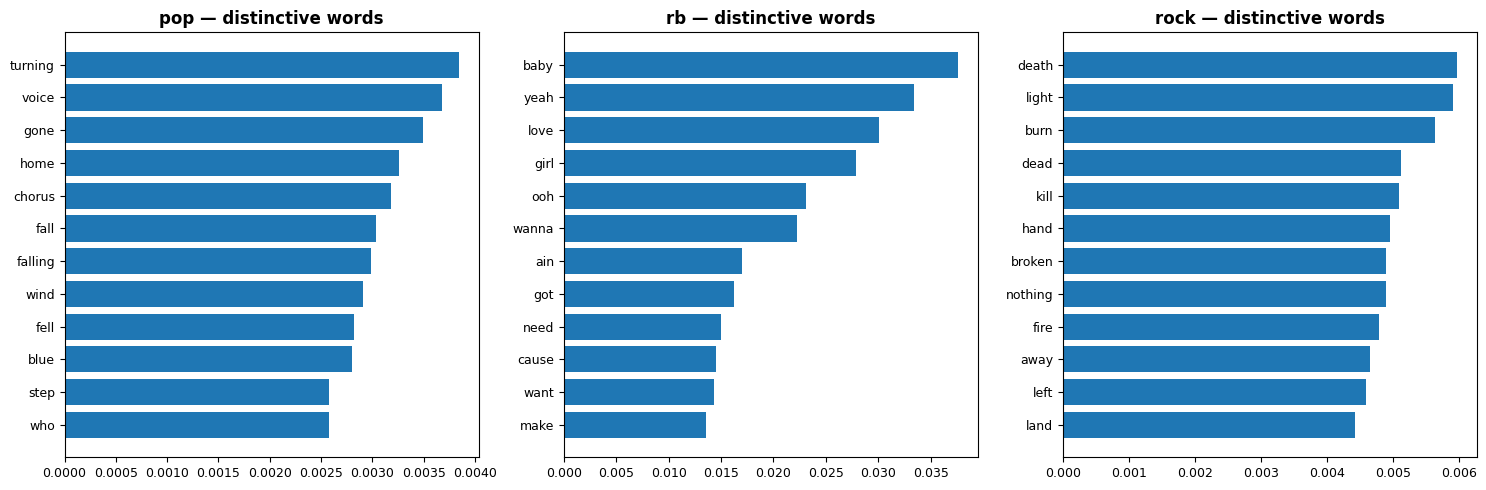

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (genre, words) in zip(axes, genre_words.items()):
    labels = [t for t, _ in words][::-1]
    scores = [s for _, s in words][::-1]
    ax.barh(labels, scores)
    ax.set_title(f"{genre} — distinctive words", fontweight="bold")
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("tfidf_genre_fingerprints.png", dpi=120, bbox_inches="tight")
plt.show()

In [32]:
exit()

We want to exclude profanities in our presentation.

In [12]:

!pip install -q better_profanity
from better_profanity import profanity
profanity.load_censor_words()   # loads the library's curated list

def is_explicit(word):
    """Delegate the explicit-word decision to the better_profanity library,
    so we don't maintain (or display) an explicit wordlist ourselves."""
    return profanity.contains_profanity(word)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.2 MB/s eta 0:00:00


Distinctive words per decade (explicit filtered):
  1980s: love, there, well, ooh, night, baby, around, hey, boy, little
  1990s: yes, little, man, need, baby, doo, cry, fool, die, way
  2000s: hey, born, live, done, cause, silence, touch, sexy, word, ain
  2010s: leave, lost, hook, body, broken, nothing, fight, verse, trying, forget
  2020s: verse, like, wanna, tryna, chorus, feeling, feel, stuck, yeah, dey

% of songs with explicit language by decade:
 decade
1980s     3.7
1990s     6.2
2000s    10.6
2010s    19.9
2020s    24.7
Name: has_explicit, dtype: float64


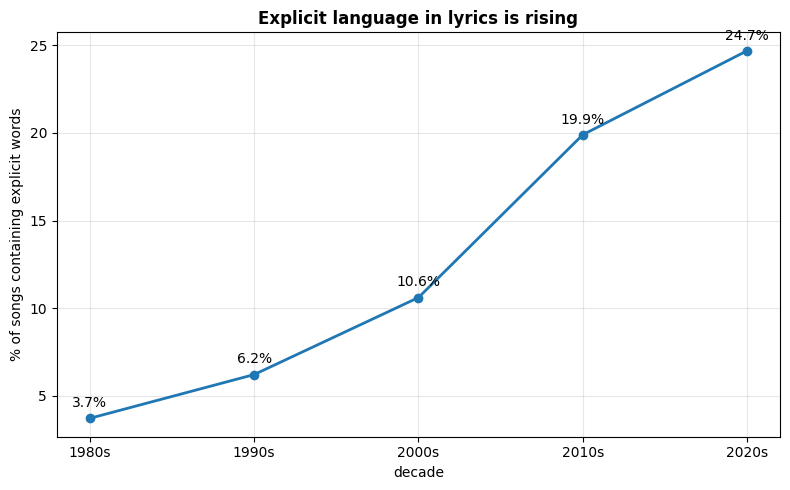

In [13]:
# === TF-IDF by decade (explicit language kept off the slides) ===
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt

def top_distinctive_clean(group_col, n=10):
    """Distinctive words per group (group mean − rest mean), skipping
    explicit terms as judged by the better_profanity library."""
    out = {}
    for g in sorted(df[group_col].unique()):
        mask = (df[group_col] == g).values
        diff = np.asarray(X[mask].mean(axis=0)).ravel() - np.asarray(X[~mask].mean(axis=0)).ravel()
        picked = []
        for i in diff.argsort()[::-1]:
            if is_explicit(terms[i]):       # library decides — nothing hardcoded
                continue
            picked.append((terms[i], diff[i]))
            if len(picked) == n:
                break
        out[g] = picked
    return out

decade_words = top_distinctive_clean("decade")
print("Distinctive words per decade (explicit filtered):")
for d, w in decade_words.items():
    print(f"  {d}: {', '.join(t for t,_ in w)}")

expl_re = re.compile(r"\b(" + "|".join(EXPLICIT) + r")\b")
df["has_explicit"] = df["clean_text"].fillna("").apply(lambda t: bool(expl_re.search(t)))
pct = (df.groupby("decade")["has_explicit"].mean() * 100).round(1)
print("\n% of songs with explicit language by decade:\n", pct)

plt.figure(figsize=(8, 5))
plt.plot(pct.index, pct.values, marker="o", linewidth=2)
plt.title("Explicit language in lyrics is rising", fontweight="bold")
plt.ylabel("% of songs containing explicit words")
plt.xlabel("decade")
plt.grid(alpha=0.3)
for x, y in zip(pct.index, pct.values):
    plt.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.savefig("explicit_by_decade.png", dpi=120, bbox_inches="tight")
plt.show()

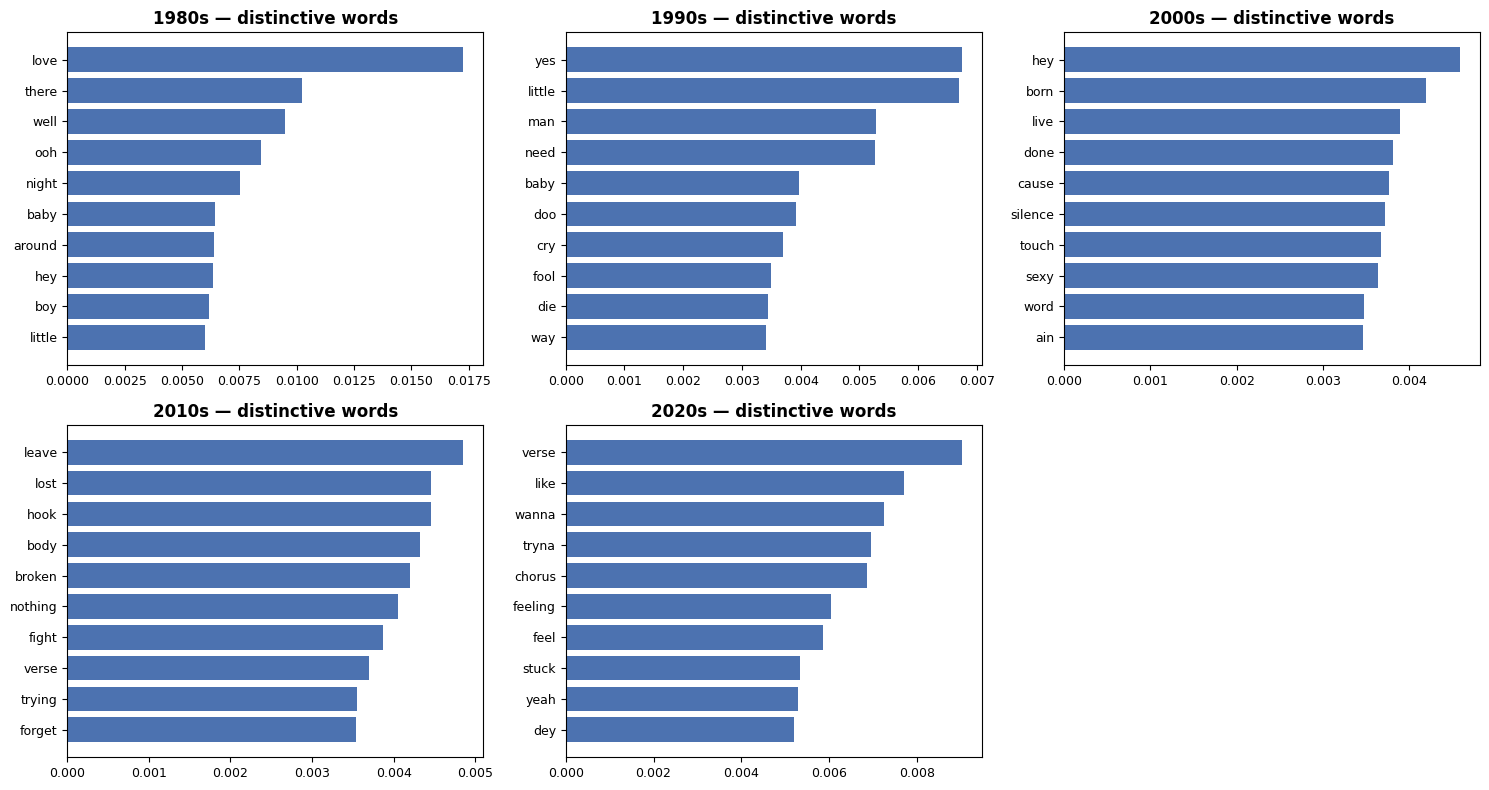

In [10]:
# === Per-decade distinctive-words chart (explicit filtered) ===
import matplotlib.pyplot as plt

decade_words = top_distinctive_clean("decade", n=10)   # from your decade cell

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (decade, words) in zip(axes, decade_words.items()):
    labels = [t for t, _ in words][::-1]
    scores = [s for _, s in words][::-1]
    ax.barh(labels, scores, color="#4C72B0")
    ax.set_title(f"{decade} — distinctive words", fontweight="bold")
    ax.tick_params(labelsize=9)

# hide the unused 6th panel (5 decades in a 2x3 grid)
for ax in axes[len(decade_words):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("tfidf_decade_fingerprints.png", dpi=120, bbox_inches="tight")
plt.show()